In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
print("Libraries loaded successfully!")


Libraries loaded successfully!


In [2]:
df1 = pd.read_csv('Friday-WorkingHours-Morning.pcap_ISCX.csv')
df2 = pd.read_csv('Wednesday-workingHours.pcap_ISCX.csv')

df = pd.concat([df1, df2], ignore_index=True)
print(f"Total rows loaded: {len(df):,}")
print(f"Total columns: {df.shape[1]}")

Total rows loaded: 883,736
Total columns: 79


In [3]:
df.columns = df.columns.str.strip()
print("Attack types in this dataset:")
print(df['Label'].value_counts())

Attack types in this dataset:
Label
BENIGN              629098
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Bot                   1966
Heartbleed              11
Name: count, dtype: int64


In [4]:
print(f"Rows before cleaning: {len(df):,}")
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
print(f"Rows after cleaning:  {len(df):,}")
print(f"Rows removed: {900000 - len(df):,}")

Rows before cleaning: 883,736
Rows after cleaning:  882,317
Rows removed: 17,683


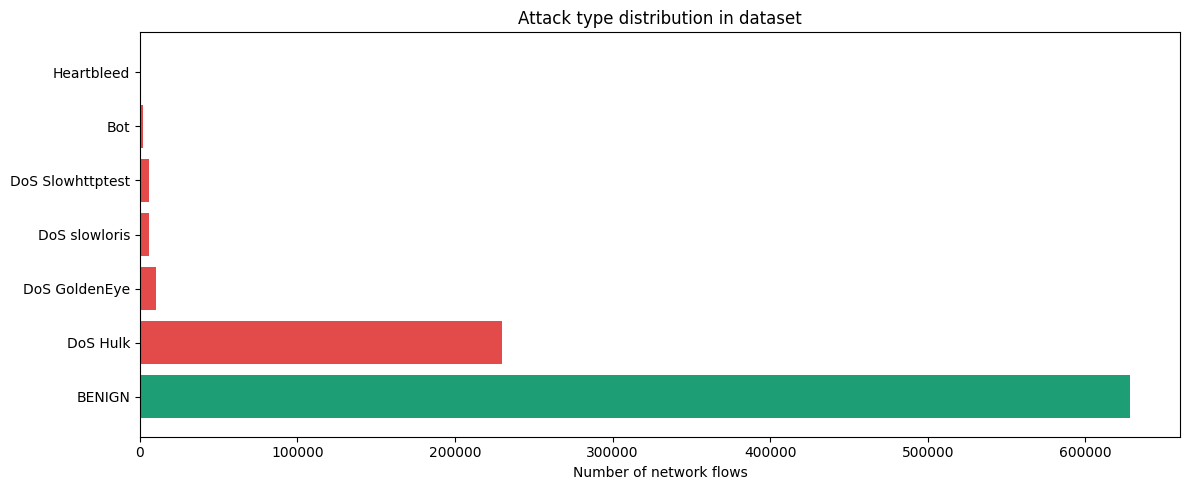

Chart saved as attack_distribution.png


In [5]:
plt.figure(figsize=(12, 5))
counts = df['Label'].value_counts()
colors = ['#E24B4A' if x != 'BENIGN' else '#1D9E75' for x in counts.index]
plt.barh(counts.index, counts.values, color=colors)
plt.title('Attack type distribution in dataset')
plt.xlabel('Number of network flows')
plt.tight_layout()
plt.savefig('attack_distribution.png', dpi=150)
plt.show()
print("Chart saved as attack_distribution.png")

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['Label'])

print("Label number mapping:")
for i, name in enumerate(le.classes_):
    print(f"  {i}  →  {name}")

Label number mapping:
  0  →  BENIGN
  1  →  Bot
  2  →  DoS GoldenEye
  3  →  DoS Hulk
  4  →  DoS Slowhttptest
  5  →  DoS slowloris
  6  →  Heartbleed


In [7]:
df.to_csv('../data/cleaned_dataset.csv', index=False)
print(f"Saved! {len(df):,} rows in cleaned_dataset.csv")

import joblib
joblib.dump(le, '../ml-engine/label_encoder.pkl')
print("Label encoder saved to ml-engine/label_encoder.pkl")

Saved! 882,317 rows in cleaned_dataset.csv
Label encoder saved to ml-engine/label_encoder.pkl


In [8]:
print("=" * 40)
print("DAY 1 COMPLETE — Summary")
print("=" * 40)
print(f"Total flows:    {len(df):,}")
print(f"Attack types:   {df['Label'].nunique()}")
print(f"Features:       {df.select_dtypes(include=np.number).shape[1]}")
normal = (df['Label'] == 'BENIGN').sum()
attack = (df['Label'] != 'BENIGN').sum()
print(f"Normal traffic: {normal:,}")
print(f"Attack traffic: {attack:,}")
print(f"Attack ratio:   {attack/len(df)*100:.1f}%")

DAY 1 COMPLETE — Summary
Total flows:    882,317
Attack types:   7
Features:       79
Normal traffic: 628,638
Attack traffic: 253,679
Attack ratio:   28.8%
